**Celda 0 Librerías**

In [ ]:
!pip install numpy pandas openpyxl

**Celda 1: Opcion subir .zip**

In [ ]:
from google.colab import files
import zipfile
import os

# Se abrirá un selector de archivos: elige el .zip de KINECT_Skeleton_Data
subido = files.upload()
nombre_zip = list(subido.keys())[0]

with zipfile.ZipFile(nombre_zip, 'r') as z:
    z.extractall('/content/datos')

CARPETA_DATOS = '/content/datos/'
CARPETA_SKELETON = '/content/datos/KINECT_Skeleton_Data/'

archivos_skeleton = [f for f in os.listdir(CARPETA_SKELETON) if f.endswith('.skeleton')]
print(f'Listo. Archivos .skeleton extraídos: {len(archivos_skeleton)}')

Saving KINECT_Skeleton_Data.zip to KINECT_Skeleton_Data.zip
Listo. Archivos .skeleton extraídos: 631


**Celda 2: Imports y parser de .skeleton**

In [ ]:
import re
import glob
import os
import numpy as np
import pandas as pd

JOINT_NAMES = [
    "SpineBase", "SpineMid", "Neck", "Head",
    "ShoulderLeft", "ElbowLeft", "WristLeft", "HandLeft",
    "ShoulderRight", "ElbowRight", "WristRight", "HandRight",
    "HipLeft", "KneeLeft", "AnkleLeft", "FootLeft",
    "HipRight", "KneeRight", "AnkleRight", "FootRight",
    "SpineShoulder",
    "HandTipLeft", "ThumbLeft", "HandTipRight", "ThumbRight",
]

J = {name: i for i, name in enumerate(JOINT_NAMES)}

def parse_skeleton(filepath):
    """Lee un archivo .skeleton y devuelve un array (n_frames, 25, 3) de posiciones XYZ."""
    with open(filepath, "r") as f:
        lines = [ln.strip() for ln in f if ln.strip() != ""]

    idx = 0
    frame_count = int(lines[idx]); idx += 1
    frames = []

    for _ in range(frame_count):
        body_count = int(lines[idx]); idx += 1
        frame_joints = None
        for _b in range(body_count):
            idx += 1  # linea de info del cuerpo
            joint_count = int(lines[idx]); idx += 1
            joints = np.zeros((joint_count, 3))
            for j in range(joint_count):
                vals = lines[idx].split()
                idx += 1
                joints[j] = [float(vals[0]), float(vals[1]), float(vals[2])]
            if frame_joints is None:
                frame_joints = joints

        # Manejo seguro si no se detecta cuerpo en el frame
        frames.append(frame_joints if frame_joints is not None else np.full((25, 3), np.nan))

    return np.array(frames)

**Celda 3: Biomarcadores de Ejercicio**

---



In [ ]:
# Celda 3: extracción de biomarcadores de alineación de rodilla

def _suavizar_trayectoria(datos, ventana=5, limite_interpolacion=3):
    """
    Interpola pérdidas cortas y aplica una mediana móvil.
    datos debe tener forma (n_frames, 3).
    """
    datos = np.asarray(datos, dtype=float)
    resultado = np.full_like(datos, np.nan)

    for coordenada in range(3):
        serie = pd.Series(datos[:, coordenada])
        serie = serie.replace([np.inf, -np.inf], np.nan)

        # Solo se interpolan pérdidas cortas para no inventar segmentos largos
        serie = serie.interpolate(
            limit=limite_interpolacion,
            limit_direction="both"
        )

        serie = serie.rolling(
            window=ventana,
            center=True,
            min_periods=1
        ).median()

        resultado[:, coordenada] = serie.to_numpy()

    return resultado


def _normalizar_vector(vector):
    norma = np.linalg.norm(vector)

    if not np.isfinite(norma) or norma < 1e-9:
        return None

    return vector / norma


def _crear_ejes_corporales(joints):
    """
    Construye ejes fijos para toda la grabación.

    lateral: izquierda-derecha
    vertical: inferior-superior
    frontal: perpendicular al plano coronal
    """
    spine_base = joints[:, J["SpineBase"]]
    spine_shoulder = joints[:, J["SpineShoulder"]]

    hip_left = joints[:, J["HipLeft"]]
    hip_right = joints[:, J["HipRight"]]

    # Eje vertical promedio del cuerpo
    vertical = np.nanmedian(
        spine_shoulder - spine_base,
        axis=0
    )
    vertical = _normalizar_vector(vertical)

    if vertical is None:
        vertical = np.array([0.0, 1.0, 0.0])

    # Eje lateral promedio de las caderas
    lateral = np.nanmedian(
        hip_right - hip_left,
        axis=0
    )

    # Hacerlo perpendicular al eje vertical
    lateral = lateral - np.dot(lateral, vertical) * vertical
    lateral = _normalizar_vector(lateral)

    if lateral is None:
        lateral = np.array([1.0, 0.0, 0.0])
        lateral = lateral - np.dot(lateral, vertical) * vertical
        lateral = _normalizar_vector(lateral)

    frontal = np.cross(lateral, vertical)
    frontal = _normalizar_vector(frontal)

    return lateral, vertical, frontal


def _proyectar_plano_coronal(punto, origen, lateral, vertical):
    """
    Convierte un punto 3D a coordenadas corporales 2D:
    [posición lateral, posición vertical].
    """
    vector = punto - origen

    return np.array([
        np.dot(vector, lateral),
        np.dot(vector, vertical)
    ])


def _desviacion_rodilla(cadera, rodilla, tobillo, lado):
    """
    Distancia con signo entre la rodilla y la línea cadera-tobillo.

    El resultado se ajusta para que:
        positivo = movimiento hacia dentro
        negativo = movimiento hacia fuera
    """
    linea_pierna = tobillo - cadera
    vector_rodilla = rodilla - cadera

    longitud_linea = np.linalg.norm(linea_pierna)

    if not np.isfinite(longitud_linea) or longitud_linea < 1e-9:
        return np.nan

    producto_cruzado_2d = (
        linea_pierna[0] * vector_rodilla[1]
        - linea_pierna[1] * vector_rodilla[0]
    )

    distancia = producto_cruzado_2d / longitud_linea

    # En la pierna derecha se invierte el signo para que
    # ambos lados tengan la misma interpretación
    if lado == "right":
        distancia = -distancia

    return distancia


def _angulo_articular_3d(cadera, rodilla, tobillo):
    """
    Ángulo H-K-A en 3D.

    Aproximadamente:
        180° = rodilla extendida
        valores menores = mayor flexión
    """
    vector_1 = cadera - rodilla
    vector_2 = tobillo - rodilla

    denominador = (
        np.linalg.norm(vector_1)
        * np.linalg.norm(vector_2)
    )

    if not np.isfinite(denominador) or denominador < 1e-9:
        return np.nan

    coseno = np.dot(vector_1, vector_2) / denominador
    coseno = np.clip(coseno, -1.0, 1.0)

    return np.degrees(np.arccos(coseno))


def extraer_serie_alineacion_ex2(joints, ventana=5):
    """
    Extrae la alineación cadera-rodilla-tobillo en cada frame.

    Retorna un DataFrame con una fila por frame.
    """
    joints = np.asarray(joints, dtype=float).copy()

    if joints.ndim != 3 or joints.shape[1] < 20 or joints.shape[2] < 3:
        raise ValueError(
            "joints debe tener forma (n_frames, 25, 3)"
        )

    # Coordenadas completamente en cero se consideran inválidas
    articulaciones_cero = np.all(
        np.isclose(joints, 0.0),
        axis=2
    )
    joints[articulaciones_cero] = np.nan

    # Suavizado de cada articulación
    for articulacion in range(joints.shape[1]):
        joints[:, articulacion, :] = _suavizar_trayectoria(
            joints[:, articulacion, :],
            ventana=ventana
        )

    lateral, vertical, _ = _crear_ejes_corporales(joints)

    hip_left = joints[:, J["HipLeft"]]
    hip_right = joints[:, J["HipRight"]]

    origenes = (hip_left + hip_right) / 2.0

    filas = []

    for frame in range(len(joints)):
        fila = {"frame": frame}

        for lado, sufijo in [
            ("left", "izq"),
            ("right", "der")
        ]:
            nombre_cadera = (
                "HipLeft" if lado == "left" else "HipRight"
            )
            nombre_rodilla = (
                "KneeLeft" if lado == "left" else "KneeRight"
            )
            nombre_tobillo = (
                "AnkleLeft" if lado == "left" else "AnkleRight"
            )

            cadera_3d = joints[frame, J[nombre_cadera]]
            rodilla_3d = joints[frame, J[nombre_rodilla]]
            tobillo_3d = joints[frame, J[nombre_tobillo]]

            puntos = np.vstack([
                cadera_3d,
                rodilla_3d,
                tobillo_3d
            ])

            if not np.all(np.isfinite(puntos)):
                fila[f"desv_{sufijo}_m"] = np.nan
                fila[f"long_pierna_{sufijo}_m"] = np.nan
                fila[f"angulo_rodilla_{sufijo}_deg"] = np.nan
                continue

            cadera_2d = _proyectar_plano_coronal(
                cadera_3d,
                origenes[frame],
                lateral,
                vertical
            )

            rodilla_2d = _proyectar_plano_coronal(
                rodilla_3d,
                origenes[frame],
                lateral,
                vertical
            )

            tobillo_2d = _proyectar_plano_coronal(
                tobillo_3d,
                origenes[frame],
                lateral,
                vertical
            )

            desviacion = _desviacion_rodilla(
                cadera_2d,
                rodilla_2d,
                tobillo_2d,
                lado
            )

            longitud_pierna = (
                np.linalg.norm(cadera_3d - rodilla_3d)
                + np.linalg.norm(rodilla_3d - tobillo_3d)
            )

            angulo_rodilla = _angulo_articular_3d(
                cadera_3d,
                rodilla_3d,
                tobillo_3d
            )

            fila[f"desv_{sufijo}_m"] = desviacion
            fila[f"long_pierna_{sufijo}_m"] = longitud_pierna
            fila[f"angulo_rodilla_{sufijo}_deg"] = angulo_rodilla

        spine_base = joints[frame, J["SpineBase"]]

        if np.all(np.isfinite(spine_base)):
            fila["altura_pelvis"] = np.dot(
                spine_base,
                vertical
            )
        else:
            fila["altura_pelvis"] = np.nan

        filas.append(fila)

    serie = pd.DataFrame(filas)

    # Normalización usando la longitud mediana de cada pierna
    for sufijo in ["izq", "der"]:
        longitud_mediana = np.nanmedian(
            serie[f"long_pierna_{sufijo}_m"]
        )

        if np.isfinite(longitud_mediana) and longitud_mediana > 1e-9:
            serie[f"desv_{sufijo}_norm"] = (
                serie[f"desv_{sufijo}_m"]
                / longitud_mediana
            )
        else:
            serie[f"desv_{sufijo}_norm"] = np.nan

    # Postura neutral: 20 % de frames con pelvis más alta
    alturas_validas = serie["altura_pelvis"].dropna()

    if len(alturas_validas) > 0:
        limite_superior = np.nanquantile(
            alturas_validas,
            0.80
        )

        frames_neutrales = (
            serie["altura_pelvis"] >= limite_superior
        )
    else:
        frames_neutrales = pd.Series(
            False,
            index=serie.index
        )

    # Restar la alineación neutral individual
    for sufijo in ["izq", "der"]:
        referencia = np.nanmedian(
            serie.loc[
                frames_neutrales,
                f"desv_{sufijo}_norm"
            ]
        )

        if not np.isfinite(referencia):
            referencia = np.nanmedian(
                serie[f"desv_{sufijo}_norm"]
            )

        serie[f"desv_{sufijo}_rel"] = (
            serie[f"desv_{sufijo}_norm"]
            - referencia
        )

    # Identificación aproximada de frames activos de la sentadilla
    angulo_promedio = serie[
        [
            "angulo_rodilla_izq_deg",
            "angulo_rodilla_der_deg"
        ]
    ].mean(axis=1)

    angulo_referencia = np.nanmedian(
        angulo_promedio[frames_neutrales]
    )

    if not np.isfinite(angulo_referencia):
        angulos_validos = angulo_promedio.dropna()

        if len(angulos_validos) > 0:
            angulo_referencia = np.nanpercentile(
                angulos_validos,
                80
            )

    if np.isfinite(angulo_referencia):
        serie["fase_activa"] = (
            angulo_promedio < angulo_referencia - 10.0
        )
    else:
        serie["fase_activa"] = True

    return serie


def _maximo_seguro(datos):
    datos = np.asarray(datos, dtype=float)
    datos = datos[np.isfinite(datos)]

    if len(datos) == 0:
        return np.nan

    return float(np.max(datos))


def _media_segura(datos):
    datos = np.asarray(datos, dtype=float)
    datos = datos[np.isfinite(datos)]

    if len(datos) == 0:
        return np.nan

    return float(np.mean(datos))


def extraer_biomarcadores_ex2(joints, umbral=0.03):
    """
    Resume toda la sentadilla en biomarcadores escalares.

    umbral=0.03 significa una desviación equivalente
    al 3 % de la longitud de la pierna.
    """
    serie = extraer_serie_alineacion_ex2(joints)

    frames_activos = serie[serie["fase_activa"]].copy()

    # Si no se detectó suficientemente la fase activa,
    # se utiliza la grabación completa
    if len(frames_activos) < 3:
        frames_activos = serie.copy()

    resultado = {}

    for sufijo in ["izq", "der"]:
        desviacion = frames_activos[
            f"desv_{sufijo}_rel"
        ].to_numpy(dtype=float)

        valores_validos = desviacion[
            np.isfinite(desviacion)
        ]

        if len(valores_validos) == 0:
            resultado[f"valgo_max_{sufijo}"] = np.nan
            resultado[f"varo_max_{sufijo}"] = np.nan
            resultado[f"desv_media_{sufijo}"] = np.nan
            resultado[f"pct_frames_valgo_{sufijo}"] = np.nan
            resultado[f"pct_frames_varo_{sufijo}"] = np.nan
            continue

        # Positivo = hacia dentro
        resultado[f"valgo_max_{sufijo}"] = _maximo_seguro(
            np.maximum(valores_validos, 0.0)
        )

        # Negativo = hacia fuera
        resultado[f"varo_max_{sufijo}"] = _maximo_seguro(
            np.maximum(-valores_validos, 0.0)
        )

        resultado[f"desv_media_{sufijo}"] = _media_segura(
            valores_validos
        )

        resultado[f"pct_frames_valgo_{sufijo}"] = float(
            np.mean(valores_validos > umbral)
        )

        resultado[f"pct_frames_varo_{sufijo}"] = float(
            np.mean(valores_validos < -umbral)
        )

    valgo_izq = resultado["valgo_max_izq"]
    valgo_der = resultado["valgo_max_der"]

    if np.isfinite(valgo_izq) and np.isfinite(valgo_der):
        resultado["asimetria_valgo"] = float(
            abs(valgo_izq - valgo_der)
        )
    else:
        resultado["asimetria_valgo"] = np.nan

    resultado["valgo_max_global"] = _maximo_seguro([
        resultado["valgo_max_izq"],
        resultado["valgo_max_der"]
    ])

    resultado["varo_max_global"] = _maximo_seguro([
        resultado["varo_max_izq"],
        resultado["varo_max_der"]
    ])

    desalineado = (
        frames_activos["desv_izq_rel"].abs() > umbral
    ) | (
        frames_activos["desv_der_rel"].abs() > umbral
    )

    resultado["pct_frames_desalineados"] = float(
        desalineado.mean()
    )

    angulo_promedio = frames_activos[
        [
            "angulo_rodilla_izq_deg",
            "angulo_rodilla_der_deg"
        ]
    ].mean(axis=1)

    resultado["flexion_rodilla_min_deg"] = _maximo_seguro(
        -angulo_promedio
    )

    if np.isfinite(resultado["flexion_rodilla_min_deg"]):
        resultado["flexion_rodilla_min_deg"] *= -1

    return resultado

**Celda 4: Procesamiento de archivos**

In [ ]:
def procesar_carpeta(carpeta_skeleton, patron="Exercise_Type_5"): #O el ejercicio que hayan elegido
    archivos = sorted(glob.glob(os.path.join(carpeta_skeleton, "*.skeleton")))
    archivos = [a for a in archivos if patron.replace(" ", "_") in a.replace(" ", "_")]

    filas = []
    for ruta in archivos:
        nombre = os.path.basename(ruta)
        m = re.match(r"(P\d+)_", nombre)
        participante_id = m.group(1) if m else nombre

        joints = parse_skeleton(ruta)

        # Validación para evitar el IndexError con archivos vacíos o malformados
        if joints.ndim < 3 or joints.shape[0] == 0:
            print(f" Archivo omitido (vacío o malformado): {nombre}")
            continue

        fila = {"Partcipant Id": participante_id, "Archivo": nombre}
        biomarcadores = extraer_biomarcadores_ex2(joints)
        fila.update(biomarcadores)
        filas.append(fila)

    return pd.DataFrame(filas)

df_bio = procesar_carpeta(CARPETA_SKELETON, patron="Exercise_Type_5")
print(f"Archivos procesados correctamente: {len(df_bio)}")
df_bio.head()

Exception ignored in: <function ZipFile.__del__ at 0x7db06ead5300>
Traceback (most recent call last):
  File "/usr/lib/python3.12/zipfile/__init__.py", line 1966, in __del__
    self.close()
  File "/usr/lib/python3.12/zipfile/__init__.py", line 1983, in close
    self.fp.seek(self.start_dir)
ValueError: seek of closed file


Archivos procesados correctamente: 125


,Partcipant Id,Archivo,valgo_max_izq,varo_max_izq,desv_media_izq,pct_frames_valgo_izq,pct_frames_varo_izq,valgo_max_der,varo_max_der,desv_media_der,pct_frames_valgo_der,pct_frames_varo_der,asimetria_valgo,valgo_max_global,varo_max_global,pct_frames_desalineados,flexion_rodilla_min_deg
0,P100,P100_Male_25_Exercise Type 5.skeleton,0.000000,0.330656,-0.134995,0.000000,0.961326,0.000000,0.313466,-0.151842,0.000000,1.000000,0.000000,0.000000,0.330656,1.000000,30.763918
1,P101,P101_Female_21_Exercise Type 5.skeleton,0.138866,0.003665,0.048384,0.646739,0.000000,0.060390,0.060636,0.008779,0.173913,0.076087,0.078476,0.138866,0.060636,0.673913,112.597870
2,P102,P102_Male_21_Exercise Type 5.skeleton,0.012717,0.108979,-0.052093,0.000000,0.758621,0.002544,0.253779,-0.137754,0.000000,0.929412,0.010173,0.012717,0.253779,0.931034,59.612246
3,P103,P103_Female_22_Exercise Type 5.skeleton,0.038550,0.136255,-0.042997,0.035176,0.623116,0.149173,0.133114,0.074582,0.869347,0.035176,0.110624,0.149173,0.136255,0.934673,45.829984
4,P104,P104_Female_21_Exercise Type 5.skeleton,0.000000,0.013792,-0.008415,0.000000,0.000000,0.000000,0.001229,-0.000570,0.000000,0.000000,0.000000,0.000000,0.013792,0.000000,157.807419


**Celda 5: Cruce de datos y regresión**

**Celda 6: Exportación y descarga**

In [ ]:
from google.colab import files

SALIDA_XLSX = "biomarcadores_ejercicio5.xlsx"
with pd.ExcelWriter(SALIDA_XLSX, engine="openpyxl") as writer:
    df_bio.to_excel(writer, sheet_name="Biomarcadores_Ej5", index=False)

print(f"Guardado: {SALIDA_XLSX} ({len(df_bio)} participantes)")
files.download(SALIDA_XLSX)

Guardado: biomarcadores_ejercicio5.xlsx (125 participantes)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Celda 7 prueba

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df_scores=pd.read_csv('Participants_with_Performance_Scores.csv')
try:
  df_unido = pd.merge(df_bio, df_scores, on='Partcipant Id', how= 'inner')
  print(f"Base de datos unidas con éxito. total de pacientes: {len(df_unido)}")
except KeyError:
  print("Revisar el nombre de la columna")
X=df_unido.select_dtypes(include=[np.number])
print(f"La matriz X está lista y contiene {X.shape[1]} características") # Incluye los scores clínicos

Base de datos unidas con éxito. total de pacientes: 618
La matriz X está lista y contiene 17 características


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (silhouette_score, calinski_harabasz_score, davies_bouldin_score, adjusted_rand_score, normalized_mutual_info_score)

RANDOM_STATE=42

BIOMARCADORES = [
    "valgo_max_izq",
    "valgo_max_der",
    "varo_max_izq",
    "varo_max_der",
    "desv_media_izq",
    "desv_media_der",
    "pct_frames_valgo_izq",
    "pct_frames_valgo_der",
    "pct_frames_varo_izq",
    "pct_frames_varo_der",
    "asimetria_valgo",
    "valgo_max_global",
    "varo_max_global",
    "pct_frames_desalineados",
    "flexion_rodilla_min_deg",
    "Performance Outcome",
    "Control Factor"
]

In [ ]:
def preparar_datos(df_unido, columnas, BIOMARCADORES):
  cols_presentes=[c for c in columnas if c in df_unido.columns]
  X=df_unido[cols_presentes].dropna()
  scaler=StandardScaler()
  X_scaled=scaler.fit_transform(X)
  idx_validos=X.index
  return X_scaled, cols_presentes, idx_validos

In [ ]:
def elegir_k (X_scaled, k_range=range(2,11)):
  inercias, siluetas= [], []
  for k in k_range:
    kmeans=KMeans(n_clusters=k, random_state=RANDOM_STATE)
    kmeans.fit(X_scaled)
    inercias.append(kmeans.inertia_)
    etiquetas=kmeans.labels_
    siluetas.append(silhouette_score(X_scaled, etiquetas))
  fig, axes=plt.subplots(1,2, figsize=(12,4))
  axes[0].plot(k_range, inercias, 'bx-')
  axes[0].set_xlabel('Número de clusters (k)')
  axes[0].set_ylabel('Inercia')
  axes[0].set_title('Método del codo')

  axes[1].plot(k_range, siluetas, 'bx-', color= 'green')
  axes[1].set_xlabel('Número de clusters (k)')
  axes[1].set_ylabel('Indice de Silueta')
  axes[1].set_title('Silueta por k')
  plt.tight_layout
  plt.savefig('elbow_silhouette.png')
  plt.show()

  for k, s in zip(k_range, siluetas):
    print(f"k: {k} Silhouette: {s}")
  return inercias, siluetas

In [ ]:
def entrenar_modelos_no_supervisados(X_scaled, k=2):
  modelos={}
  km=KMeans(n_clusters=k, random_state=RANDOM_STATE)
  km.fit(X_scaled)
  modelos['KMeans']=km.labels_

  agg=AgglomerativeClustering(n_clusters=k)
  agg.fit(X_scaled)
  modelos['Agglomerative']=agg.labels_

  db=DBSCAN(eps=2.5, min_samples=5)
  db.fit(X_scaled)
  modelos['DBSCAN']=db.labels_

  resultados=[]
  for nombre, labels in modelos.items():
    n_cluster_reales=len(set(labels)) - (1 if -1 in labels else 0)
    if n_cluster_reales <2:
      sil=np.nan
    else:
      mask=labels != -1
      sil=silhouette_score(X_scaled[mask], labels[mask]) if mask.sum()>1 else np.nan

    resultados.append({
        "modelo": nombre,
        "n_clusters": n_cluster_reales,
        "silhouette": sil,
        "calinski": calinski_harabasz_score(X_scaled, labels) if n_cluster_reales >= 2 else np.nan, # calinski needs at least 2 clusters
        "davies": davies_bouldin_score(X_scaled, labels) if n_cluster_reales >= 2 else np.nan # davies needs at least 2 clusters
        })

  return modelos, pd.DataFrame(resultados)

In [ ]:
def graficar_pca_puro(X_scaled, modelos, modelo_1="KMeans", modelo_2="Agglomerative"):
  pca=PCA(n_components=2, random_state=RANDOM_STATE)
  X_pca=pca.fit_transform(X_scaled)
  var_exp=pca.explained_variance_ratio_

  fig, ax=plt.subplots(1,2, figsize=(12,5))

  ax[0].scatter(X_pca[:,0], X_pca[:,1], c=modelos[modelo_1], cmap='viridis', s=50, edgecolors='k')
  ax[0].set_xlabel('Componente Principal 1')
  ax[0].set_ylabel('Componente Principal 2')
  ax[0].set_title(f'PCA: {modelo_1} (Varianza Explicada: {var_exp[0]:.2f}')
  ax[0].grid(True, linestyle='--', alpha=0.6)

  ax[1].scatter(X_pca[:,0], X_pca[:,1], c=modelos[modelo_2], cmap='plasma', s=50, edgecolors='k')
  ax[1].set_xlabel('Componente Principal 1')
  ax[1].set_ylabel('Componente Principal 2')
  ax[1].set_title(f'PCA: {modelo_2} (Varianza Explicada: {var_exp[1]:.2f}')
  ax[1].grid(True, linestyle='--', alpha=0.6)

  plt.tight_layout()
  plt.savefig('pca_puro.png')
  plt.show()


/tmp/ipykernel_1907/3722441011.py:15: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bx-" (-> color='b'). The keyword argument will take precedence.
  axes[1].plot(k_range, siluetas, 'bx-', color= 'green')


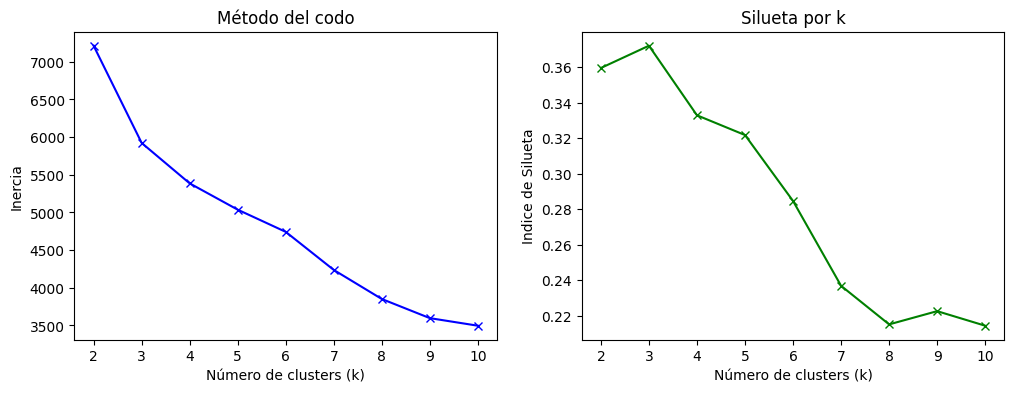

k: 2 Silhouette: 0.3594995992212522
k: 3 Silhouette: 0.37202987589317144
k: 4 Silhouette: 0.3328816744984246
k: 5 Silhouette: 0.32175659844591953
k: 6 Silhouette: 0.2846480016637113
k: 7 Silhouette: 0.23690847769793183
k: 8 Silhouette: 0.21519545843858806
k: 9 Silhouette: 0.22264132516187962
k: 10 Silhouette: 0.21444539308111663

          modelo  n_clusters  silhouette    calinski    davies
0         KMeans           8    0.215195  150.650959  1.392263
1  Agglomerative           8    0.187817  130.321861  1.258382
2         DBSCAN          25    0.196067   30.986669  1.360758


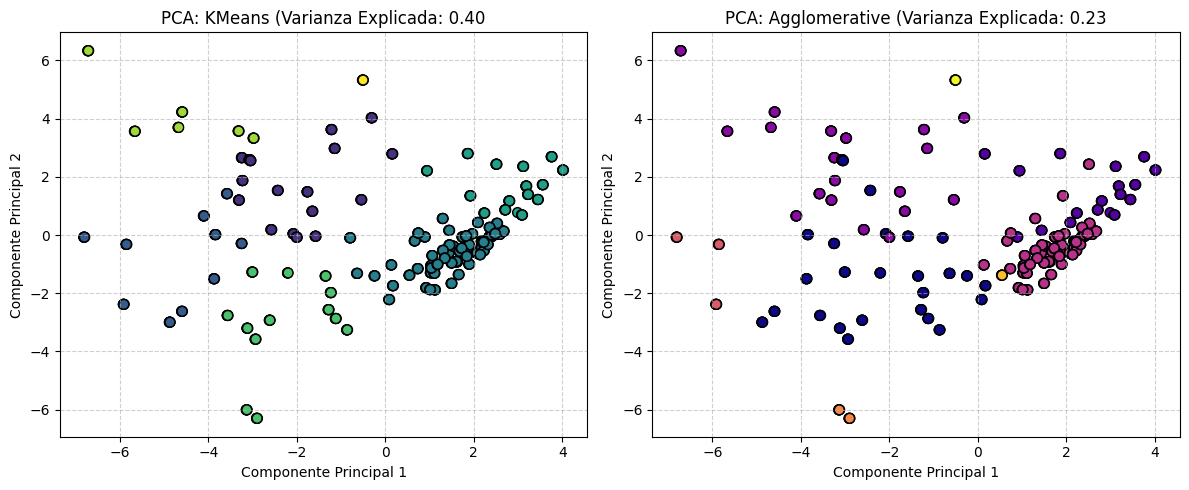

In [ ]:
X_scaled, cols_usadas, idx_validos=preparar_datos(df_unido, BIOMARCADORES, BIOMARCADORES)
elegir_k(X_scaled)
print()

k_optimo=8
modelos, resultados=entrenar_modelos_no_supervisados(X_scaled, k=k_optimo)
print(resultados)

graficar_pca_puro(X_scaled, modelos, modelo_1="KMeans", modelo_2="Agglomerative")